In [1]:
import pandas as pd
df = pd.read_csv("../data/processed/telco_processed.csv")

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,AvgMonthlySpend,ServiceCount,ContractValue
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,True,False,29.850000,1,29.85
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,True,False,False,False,True,55.573529,3,1936.30
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,True,54.075000,3,107.70
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,False,False,True,False,False,False,False,40.905556,3,1903.50
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,True,False,75.825000,1,141.40


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [3]:
X = df.drop('Churn', axis=1)

y = df['Churn']

In [4]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

In [5]:
best_lr = LogisticRegression(
    max_iter=20000
)

best_lr.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",20000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 

In [6]:
X_train_num = X_train.astype(float)

X_test_num = X_test.astype(float)

In [7]:
import shap

explainer = shap.LinearExplainer(
    best_lr,
    X_train_num
)

shap_values = explainer.shap_values(
    X_test_num
)

C:\Users\BALAJI REDDY U\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Background dataset has 4930 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=4930 when initializing the masker.


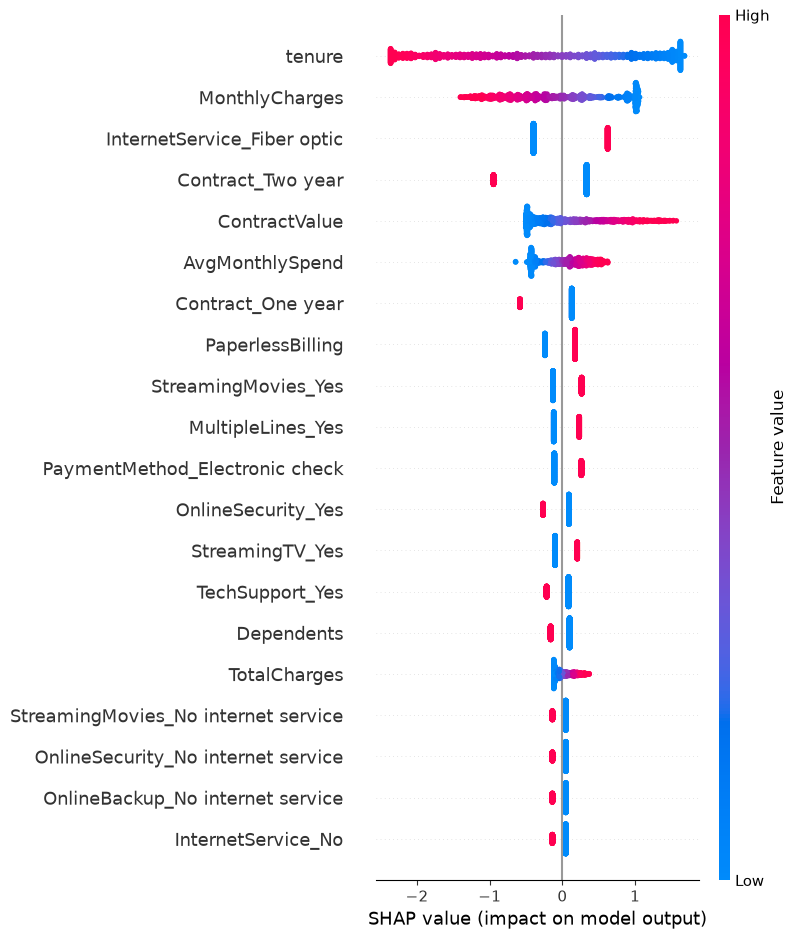

In [8]:
shap.summary_plot(
    shap_values,
    X_test_num
)

In [9]:
print(type(shap_values))
print(shap_values.shape)

<class 'numpy.ndarray'>
(1057, 33)


In [12]:
shap.initjs()
churned_idx = y_test[y_test == 1].index[0]

shap.force_plot(
    explainer.expected_value,
    shap_values[
        list(X_test_num.index).index(churned_idx)
    ],
    X_test_num.loc[churned_idx]
)

In [13]:
retained_idx = y_test[y_test == 0].index[0]

shap.force_plot(
    explainer.expected_value,
    shap_values[
        list(X_test_num.index).index(retained_idx)
    ],
    X_test_num.loc[retained_idx]
)

In [14]:
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': best_lr.coef_[0]
})

coef_df['AbsCoef'] = abs(coef_df['Coefficient'])

top3 = coef_df.sort_values(
    by='AbsCoef',
    ascending=False
)['Feature'].head(3)

print(top3)

26              Contract_Two year
11    InternetService_Fiber optic
25              Contract_One year
Name: Feature, dtype: str


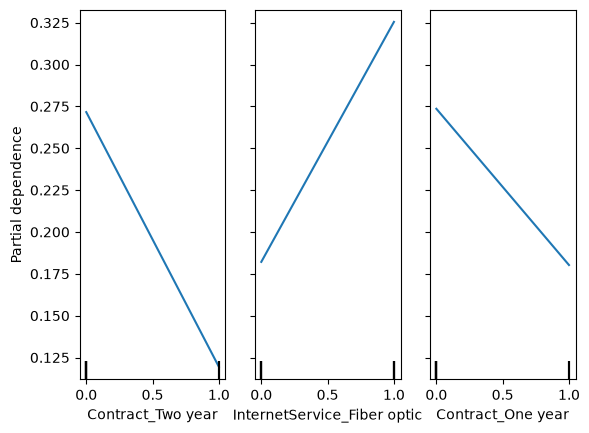

In [15]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

PartialDependenceDisplay.from_estimator(
    best_lr,
    X_test,
    top3.tolist()
)

plt.show()

In [17]:
coef_df.sort_values(
    by='AbsCoef',
    ascending=False
).head(40)

,Feature,Coefficient,AbsCoef
26,Contract_Two year,-1.281303,1.281303
11,InternetService_Fiber optic,1.021102,1.021102
25,Contract_One year,-0.712434,0.712434
6,PaperlessBilling,0.414381,0.414381
24,StreamingMovies_Yes,0.395024,0.395024
28,PaymentMethod_Electronic check,0.372150,0.372150
14,OnlineSecurity_Yes,-0.356131,0.356131
10,MultipleLines_Yes,0.350810,0.350810
22,StreamingTV_Yes,0.304449,0.304449
20,TechSupport_Yes,-0.301677,0.301677


In [18]:
probs = best_lr.predict_proba(X_test)[:,1]

risk_df = pd.DataFrame({
    'Probability': probs
}, index=X_test.index)

top100 = risk_df.sort_values(
    by='Probability',
    ascending=False
).head(100)

top100

,Probability
3380,0.847465
6866,0.827096
2797,0.823457
3727,0.813960
2631,0.811241
...,...
1783,0.646092
4473,0.645836
1125,0.643634
5750,0.642884


In [19]:
top100_idx = top100.index

actual_churners = y_test.loc[top100_idx].sum()

saved_revenue = actual_churners * 500

campaign_cost = 100 * 50

roi = ((saved_revenue - campaign_cost)
       / campaign_cost) * 100

print("Actual Churners:", actual_churners)
print("Saved Revenue:", saved_revenue)
print("Campaign Cost:", campaign_cost)
print("ROI:", roi)

Actual Churners: 76
Saved Revenue: 38000
Campaign Cost: 5000
ROI: 660.0
